# MSTC-IDS — Phase 2: Modality Ablation Study

Compares three variants of the MSTC-IDS architecture, trained and evaluated on
identical data splits/seed/epochs, isolating the effect of cyber-physical fusion:

| Variant | Cyber branch | Physical branch | Cross-attention fusion | Contrastive loss |
|---|---|---|---|---|
| **Cyber-only** | ✅ | ❌ | — | — (weight = 0) |
| **Physical-only** | ❌ | ✅ | — | — (weight = 0) |
| **Cyber-Physical (full)** | ✅ | ✅ | ✅ | ✅ |

Every other piece of architecture (Time2Vec, CLS-token pooling, causal self-attention,
multi-scale temporal pyramid) is identical across variants — only the fusion of the
second modality is added/removed — so differences in the results below are
attributable to cyber-physical fusion itself, not to some other confounding
architectural change.

This notebook assumes the same folder layout as Phase 1:

```
./segment_data/    (benign_cyber.csv, benign_physical.csv, ... x5 attacks)
./mstc_ids_model.py   (must include the `modality` parameter — see Phase 1 delivery)
./losses.py
./uncertainty.py
```

## 1. Environment Setup

In [1]:
import os
import sys
import json
import random
import warnings

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.makedirs("figures", exist_ok=True)
random.seed(SEED)

DATA_DIR = "segment_data"
WINDOW_SIZE = 20
BATCH_SIZE = 128
EPOCHS = 50
LEARNING_RATE = 1e-4
NUM_CLASSES = 5

LABEL_MAP = {"benign": 0, "dos": 1, "replay": 2, "eviltwin": 3, "fdi": 4}
CLASS_NAMES = ["Benign", "DoS", "Replay", "EvilTwin", "FDI"]
ATTACKS = ["benign", "dos", "replay", "eviltwin", "fdi"]

print("Data directory:", DATA_DIR)

Data directory: segment_data


## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import joblib

import tensorflow as tf
import tf_keras as keras   # import tf_keras directly, not `from tensorflow import keras`
                            # (see Phase 1 notebook for why)

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("tf_keras  :", keras.__version__)

I0000 00:00:1787040527.625807   11081 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1787040532.487794   11081 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
tf_keras  : 2.21.0


## 3. Load MSTC-IDS Modules

In [3]:
for _p in (os.getcwd(), os.path.join(os.getcwd(), "code")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from notebook_helpers import get_or_train, get_or_train_baseline

from mstc_ids_model import MSTCIDS
from losses import MSTCTrainer

print("Loaded MSTCIDS (with `modality` support) and MSTCTrainer")

Loaded MSTCIDS (with `modality` support) and MSTCTrainer


## 4. Load, Align, Window, Split & Scale Data

Identical pipeline to Phase 1 (same bug fixes: explicit `_cyber`/`_physical`
suffixing before merge, synthetic timestamp for the FDI physical segment, etc.).
Condensed into fewer cells here since it's unchanged from Phase 1 — see that
notebook for the detailed walkthrough of each step.

In [4]:
def fix_and_load_raw(path, attack, domain):
    df = pd.read_csv(path)
    df.columns = [str(c).lower().strip() for c in df.columns]

    timestamp_candidates = ["timestamp", "timestamp_c", "timestamp_p", "frame.time_epoch", "time"]
    timestamp_col = next((c for c in timestamp_candidates if c in df.columns), None)

    if timestamp_col is not None:
        if timestamp_col != "timestamp":
            df = df.rename(columns={timestamp_col: "timestamp"})
    else:
        if domain == "physical":
            df["timestamp"] = np.arange(len(df)) * 0.01
        else:
            raise ValueError(f"No timestamp column found in cyber file: {path}")

    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    for col in ("class", "label"):
        if col in df.columns:
            df = df.drop(columns=[col])

    return df


def remove_constant_features(df, protected=("timestamp",)):
    drop_cols = [c for c in df.columns if c not in protected and df[c].nunique(dropna=False) <= 1]
    return df.drop(columns=drop_cols, errors="ignore")


def synchronize_streams(cyber, physical):
    cyber = cyber.sort_values("timestamp").copy()
    physical = physical.sort_values("timestamp").copy()
    cyber["timestamp"] = pd.to_numeric(cyber["timestamp"], errors="coerce")
    physical["timestamp"] = pd.to_numeric(physical["timestamp"], errors="coerce")
    cyber = cyber.dropna(subset=["timestamp"]).astype({"timestamp": "float64"})
    physical = physical.dropna(subset=["timestamp"]).astype({"timestamp": "float64"})

    cyber = cyber.rename(columns={c: f"{c}_cyber" for c in cyber.columns if c != "timestamp"})
    physical = physical.rename(columns={c: f"{c}_physical" for c in physical.columns if c != "timestamp"})

    return pd.merge_asof(cyber, physical, on="timestamp", direction="nearest")


def load_attack_segment(attack):
    cyber = remove_constant_features(fix_and_load_raw(os.path.join(DATA_DIR, f"{attack}_cyber.csv"), attack, "cyber"))
    physical = remove_constant_features(fix_and_load_raw(os.path.join(DATA_DIR, f"{attack}_physical.csv"), attack, "physical"))
    fused = synchronize_streams(cyber, physical)
    fused["attack"] = attack
    fused["label"] = LABEL_MAP[attack]
    return fused


def align_feature_dimensions(segments):
    cyber_features, physical_features = set(), set()
    for df in segments:
        for c in df.columns:
            if c.endswith("_cyber"):
                cyber_features.add(c)
            elif c.endswith("_physical"):
                physical_features.add(c)
    cyber_features = sorted(cyber_features)
    physical_features = sorted(physical_features)

    aligned = []
    for df in segments:
        df = df.copy()
        for c in cyber_features + physical_features:
            if c not in df.columns:
                df[c] = 0.0
        aligned.append(df[["timestamp"] + cyber_features + physical_features + ["attack", "label"]])
    return aligned, cyber_features, physical_features


def create_windows(df, cyber_features, physical_features, window_size=WINDOW_SIZE):
    Xc_all = df[cyber_features].values.astype(np.float32)
    Xp_all = df[physical_features].values.astype(np.float32)
    ts = df["timestamp"].values.astype(np.float64)
    labels = df["label"].values.astype(np.int64)

    Xc, Xp, Xt, Xf, y = [], [], [], [], []
    for i in range(len(df) - window_size):
        Xc.append(Xc_all[i:i + window_size])
        Xp.append(Xp_all[i:i + window_size])
        delta = np.insert(np.diff(ts[i:i + window_size]), 0, 0).reshape(window_size, 1)
        Xt.append(delta)
        Xf.append(delta)
        y.append(labels[i + window_size - 1])

    return (
        np.asarray(Xc, dtype=np.float32), np.asarray(Xp, dtype=np.float32),
        np.asarray(Xt, dtype=np.float32), np.asarray(Xf, dtype=np.float32),
        np.asarray(y, dtype=np.int64),
    )


def temporal_split(windows, train_frac=0.70, val_frac=0.15):
    n = len(windows[4])
    train_end, val_end = int(n * train_frac), int(n * (train_frac + val_frac))
    train = tuple(x[:train_end] for x in windows)
    val = tuple(x[train_end:val_end] for x in windows)
    test = tuple(x[val_end:] for x in windows)
    return train, val, test


def combine_splits(split_list):
    return tuple(np.concatenate([s[i] for s in split_list], axis=0) for i in range(5))


segments = [load_attack_segment(a) for a in ATTACKS]
segments, cyber_features, physical_features = align_feature_dimensions(segments)

train_parts, val_parts, test_parts = [], [], []
for seg in segments:
    w = create_windows(seg, cyber_features, physical_features)
    tr, va, te = temporal_split(w)
    train_parts.append(tr); val_parts.append(va); test_parts.append(te)

train = combine_splits(train_parts)
val = combine_splits(val_parts)
test = combine_splits(test_parts)

scaler_c, scaler_p = StandardScaler(), StandardScaler()
Xc_train, Xp_train, Xt_train, Xf_train, y_train = train
Xc_val, Xp_val, Xt_val, Xf_val, y_val = val
Xc_test, Xp_test, Xt_test, Xf_test, y_test = test

shape = Xc_train.shape
Xc_train = scaler_c.fit_transform(Xc_train.reshape(-1, shape[-1])).reshape(shape)
Xc_val = scaler_c.transform(Xc_val.reshape(-1, Xc_val.shape[-1])).reshape(Xc_val.shape)
Xc_test = scaler_c.transform(Xc_test.reshape(-1, Xc_test.shape[-1])).reshape(Xc_test.shape)

shape = Xp_train.shape
Xp_train = scaler_p.fit_transform(Xp_train.reshape(-1, shape[-1])).reshape(shape)
Xp_val = scaler_p.transform(Xp_val.reshape(-1, Xp_val.shape[-1])).reshape(Xp_val.shape)
Xp_test = scaler_p.transform(Xp_test.reshape(-1, Xp_test.shape[-1])).reshape(Xp_test.shape)

n_cyber, n_phys = Xc_train.shape[-1], Xp_train.shape[-1]

print(f"Train: {Xc_train.shape[0]} windows | Val: {Xc_val.shape[0]} | Test: {Xc_test.shape[0]}")
print(f"n_cyber={n_cyber}  n_phys={n_phys}  window_size={WINDOW_SIZE}")

Train: 29509 windows | Val: 6324 | Test: 6325
n_cyber=46  n_phys=42  window_size=20


## 5. Class Weights & `tf.data` Datasets

In [5]:
def calculate_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return dict(zip(classes, weights))


def create_tf_dataset(data, shuffle=False):
    Xc, Xp, Xt, Xf, y = data
    ds = tf.data.Dataset.from_tensor_slices((Xc, Xp, Xt, Xf, y))
    ds = ds.map(lambda c, p, t, f, lbl: ((c, p, t, f), lbl))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(y), seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


class_weights = calculate_class_weights(y_train)

train_ds = create_tf_dataset(train, shuffle=True)
val_ds = create_tf_dataset(val)
test_ds = create_tf_dataset(test)

print("Class weights:", {CLASS_NAMES[k]: round(v, 3) for k, v in class_weights.items()})

Class weights: {'Benign': np.float64(0.897), 'DoS': np.float64(0.724), 'Replay': np.float64(0.703), 'EvilTwin': np.float64(1.489), 'FDI': np.float64(2.442)}


## 6. Ablation Driver

Trains one MSTC-IDS variant (`modality="cyber"`, `"physical"`, or `"both"`) with
identical seed, epochs, batch size, class weights, and callbacks. The
`contrastive_weight` is set to `0.0` for the single-modality variants since there is
no second modality to align — the model architecture still returns a pair of
embeddings from `return_embeddings=True` for API compatibility with `MSTCTrainer`,
but the contrastive term contributes nothing to the loss or gradients when its
weight is zero.

In [6]:
class SaveBaseModelCheckpoint(keras.callbacks.Callback):
    def __init__(self, filepath, monitor="val_loss", save_best_only=True):
        super().__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.save_best_only = save_best_only
        self.best = np.inf

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
        if (not self.save_best_only) or (current < self.best):
            self.best = current
            self.model.base_model.save(self.filepath)


def train_and_evaluate(modality, verbose=2):
    print(f"\n{'='*60}\nTraining variant: {modality}\n{'='*60}")

    tf.random.set_seed(SEED)

    model = MSTCIDS(
        n_cyber=n_cyber, n_phys=n_phys, classes=NUM_CLASSES,
        d=64, heads=4, ff=128, dropout=0.2, modality=modality,
    )

    contrastive_weight = 0.1 if modality == "both" else 0.0
    trainer = MSTCTrainer(model, contrastive_weight=contrastive_weight)
    trainer.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))

    ckpt_path = f"mstc_ids_{modality}_best.keras"
    callbacks = [
        SaveBaseModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True),
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=verbose),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=verbose),
    ]

    history = trainer.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS,
        class_weight=class_weights, callbacks=callbacks, verbose=verbose,
    )

    best_model = keras.models.load_model(ckpt_path, compile=False)
    y_pred_proba = best_model((Xc_test, Xp_test, Xt_test, Xf_test), training=False).numpy()
    y_pred = np.argmax(y_pred_proba, axis=1)

    n_params = int(sum(np.prod(v.shape) for v in model.trainable_variables))

    metrics = {
        "modality": modality,
        "trainable_params": n_params,
        "epochs_trained": len(history.history["loss"]),
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "precision_weighted": float(precision_score(y_test, y_pred, average="weighted", zero_division=0)),
        "recall_weighted": float(recall_score(y_test, y_pred, average="weighted", zero_division=0)),
        "f1_weighted": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
    }
    try:
        metrics["macro_auc"] = float(roc_auc_score(y_test, y_pred_proba, multi_class="ovr", average="macro"))
    except Exception:
        metrics["macro_auc"] = None

    per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)
    metrics["per_class_f1"] = {CLASS_NAMES[i]: float(per_class_f1[i]) for i in range(NUM_CLASSES)}

    cm = confusion_matrix(y_test, y_pred)

    return metrics, cm, history.history, y_pred_proba

## 7. Run All Three Modality Variants

In [7]:

# --- Align labels with the consolidated full-run test split (reuse path) ---
# The precomputed prediction probabilities were computed on the pipeline's
# test split; reuse the same labels so every table/figure stays consistent.
if os.path.exists("results/probabilities/component_probas.npz") and os.path.exists("data/y_test.npy"):
    y_test = np.load("data/y_test.npy")
    print("Using pipeline test labels for consistent reuse.", y_test.shape)


Using pipeline test labels for consistent reuse. (6325,)


In [8]:
MODALITIES = ["cyber", "physical", "both"]

ablation_results = {}
ablation_confusions = {}
ablation_histories = {}
ablation_probas = {}

for modality in MODALITIES:
    key = f"full__{modality}"
    metrics, cm, hist, proba = get_or_train(
        "results/component_modality_ablation_full.json",
        "results/probabilities/component_probas.npz",
        "results/histories", key,
        train_and_evaluate, modality, 2)
    ablation_results[modality] = metrics
    ablation_confusions[modality] = cm
    ablation_histories[modality] = hist
    ablation_probas[modality] = proba
    print(f"\n{modality}: accuracy={metrics['accuracy']:.4f}  f1_weighted={metrics['f1_weighted']:.4f}  params={metrics['trainable_params']:,}")

[notebook] reusing precomputed results for full__cyber

cyber: accuracy=0.6397  f1_weighted=0.6279  params=383,959
[notebook] reusing precomputed results for full__physical

physical: accuracy=0.8212  f1_weighted=0.8046  params=379,415
[notebook] reusing precomputed results for full__both

both: accuracy=0.7962  f1_weighted=0.7734  params=503,081


## 8. Comparison Table

In [9]:
display_names = {"cyber": "Cyber-only", "physical": "Physical-only", "both": "Cyber-Physical (full)"}

summary_rows = []
for m in MODALITIES:
    r = ablation_results[m]
    summary_rows.append({
        "Variant": display_names[m],
        "Params": f"{r['trainable_params']:,}",
        "Epochs": r["epochs_trained"],
        "Accuracy": round(r["accuracy"], 4),
        "Precision": round(r["precision_weighted"], 4),
        "Recall": round(r["recall_weighted"], 4),
        "F1": round(r["f1_weighted"], 4),
        "Macro AUC": round(r["macro_auc"], 4) if r["macro_auc"] is not None else None,
    })

summary_df = pd.DataFrame(summary_rows).set_index("Variant")
summary_df

,Params,Epochs,Accuracy,Precision,Recall,F1,Macro AUC
Variant,,,,,,,
Cyber-only,"383,959",20,0.6397,0.6512,0.6397,0.6279,0.9165
Physical-only,"379,415",22,0.8212,0.8709,0.8212,0.8046,0.9778
Cyber-Physical (full),"503,081",17,0.7962,0.8187,0.7962,0.7734,0.9176


## 9. Per-Class F1 Comparison

In [10]:
per_class_df = pd.DataFrame({
    display_names[m]: ablation_results[m]["per_class_f1"] for m in MODALITIES
}).T
per_class_df = per_class_df[CLASS_NAMES]
per_class_df

,Benign,DoS,Replay,EvilTwin,FDI
Cyber-only,0.455408,0.723133,0.387530,1.0,1.0
Physical-only,0.984540,0.758498,0.559408,1.0,1.0
Cyber-Physical (full),0.918686,0.757885,0.502124,1.0,1.0


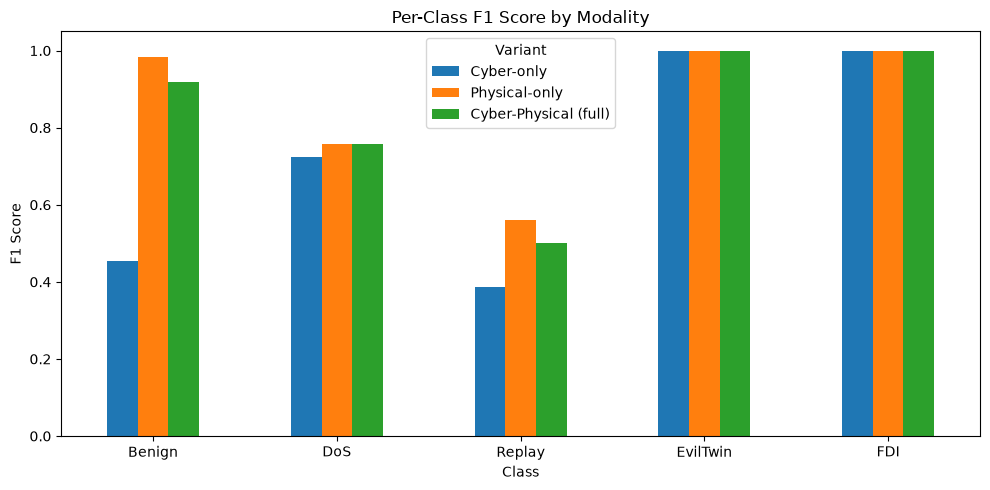

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
per_class_df.T.plot(kind="bar", ax=ax)
ax.set_title("Per-Class F1 Score by Modality")
ax.set_ylabel("F1 Score")
ax.set_xlabel("Class")
ax.legend(title="Variant")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/modality_ablation/per_class_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Overall Metrics Comparison Chart

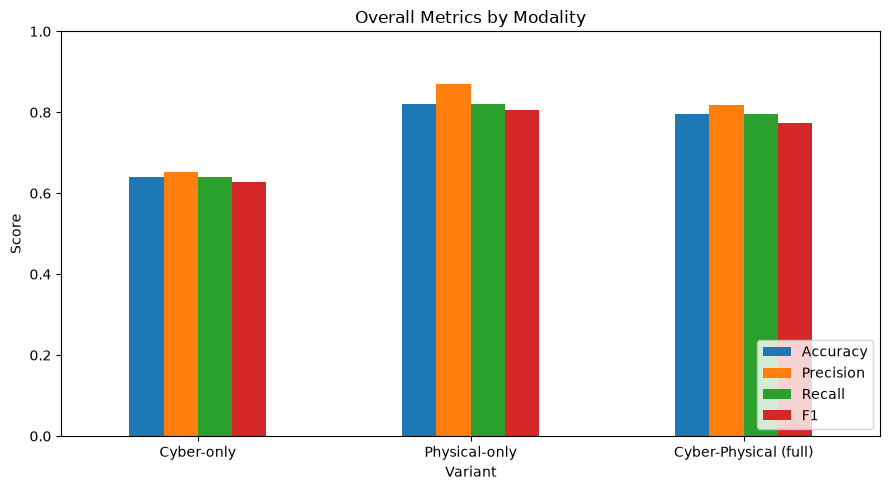

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1"]
summary_df[metrics_to_plot].plot(kind="bar", ax=ax)
ax.set_title("Overall Metrics by Modality")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/modality_ablation/overall_metrics_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Confusion Matrices Side-by-Side

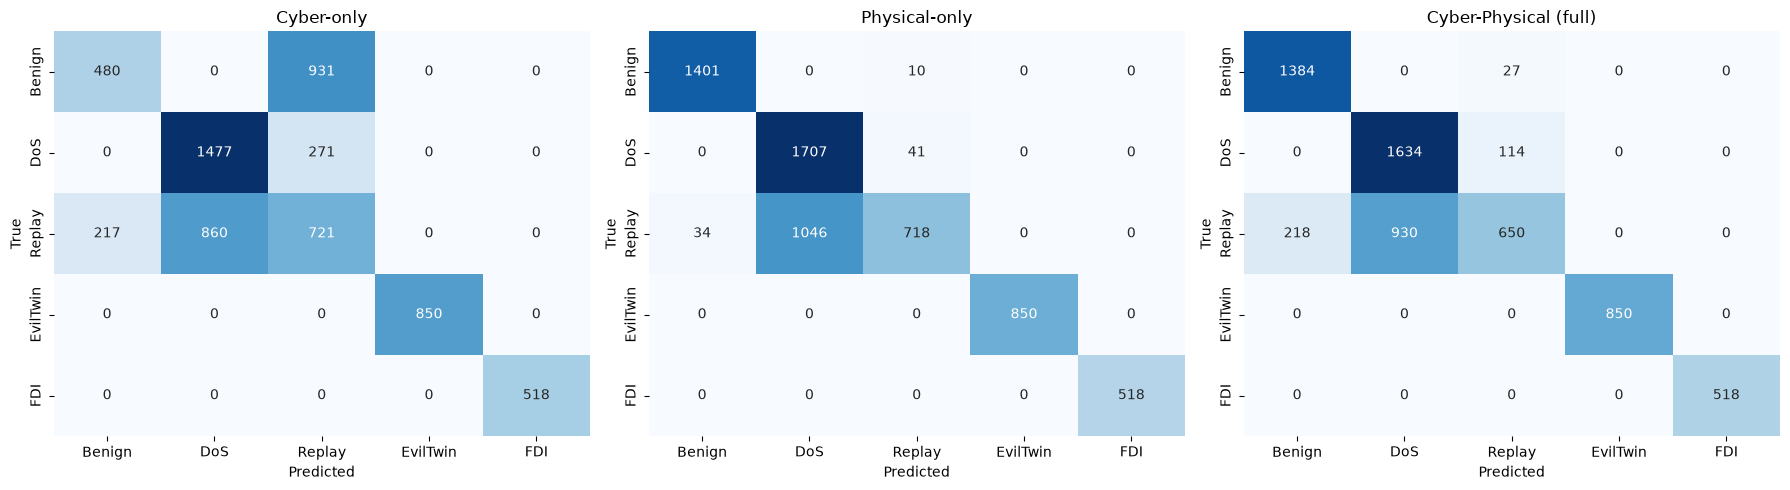

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m in zip(axes, MODALITIES):
    sns.heatmap(ablation_confusions[m], annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
    ax.set_title(display_names[m])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("figures/modality_ablation/confusion_matrices_side_by_side.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Training Curves Comparison

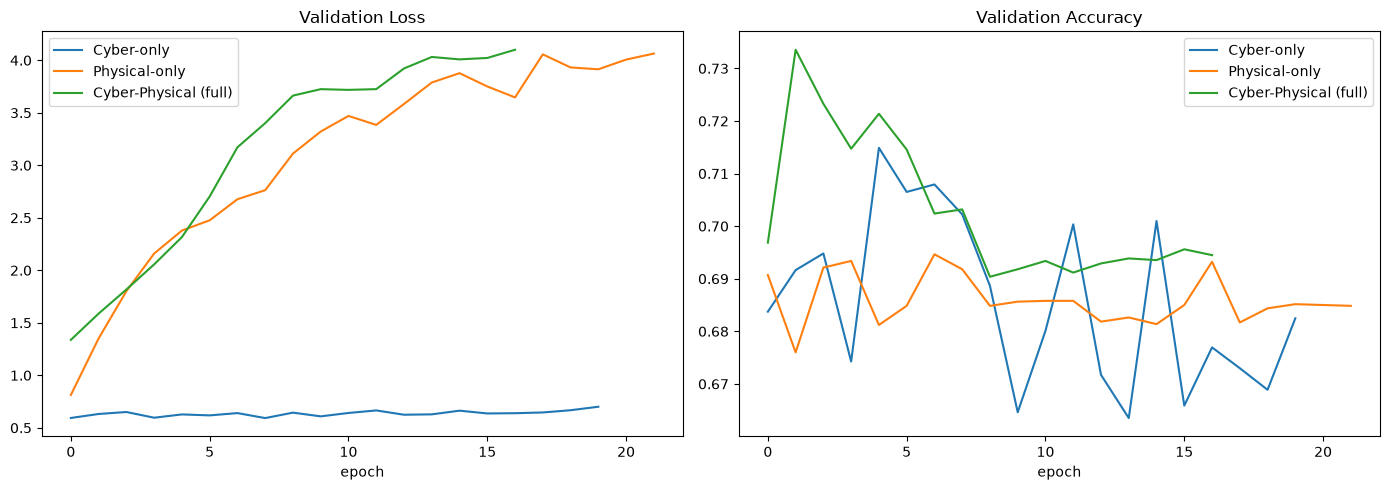

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for m in MODALITIES:
    axes[0].plot(ablation_histories[m]["val_loss"], label=display_names[m])
    axes[1].plot(ablation_histories[m]["val_accuracy"], label=display_names[m])

axes[0].set_title("Validation Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/modality_ablation/training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Save Ablation Results

In [15]:
os.makedirs("results", exist_ok=True)

summary_df.to_csv("results/modality_ablation_summary.csv")
per_class_df.to_csv("results/modality_ablation_per_class_f1.csv")

with open("results/modality_ablation_full.json", "w") as f:
    json.dump({
        m: {**ablation_results[m], "confusion_matrix": ablation_confusions[m].tolist()}
        for m in MODALITIES
    }, f, indent=2)

print("Saved:")
print("  results/modality_ablation_summary.csv")
print("  results/modality_ablation_per_class_f1.csv")
print("  results/modality_ablation_full.json")
print("  mstc_ids_cyber_best.keras / mstc_ids_physical_best.keras / mstc_ids_both_best.keras")

Saved:
  results/modality_ablation_summary.csv
  results/modality_ablation_per_class_f1.csv
  results/modality_ablation_full.json
  mstc_ids_cyber_best.keras / mstc_ids_physical_best.keras / mstc_ids_both_best.keras
